In [ ]:
#Global Tech Job Market and Career Trajectories (2019-2026)
# Exploratory Data Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [ ]:
df = pd.read_csv('/content/tech_job_market_2019_2026.csv')
df

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114995,JOB012896,EmberReach Technologies,FAANG-tier,HealthTech,57977,UK,Software Engineer,Lead,7,16,...,2025-11-14 00:00:00,2025-12-21,Filled,45.0,6.0,1.0,1.0,215300.0,254300.0,Yes
114996,JOB060961,AstraSuite,MNC,HealthTech,163658,Brazil,Data Scientist,Senior,4,10,...,NaN,NaN,Open,57.0,4.0,1.0,0.0,87500.0,113500.0,0
114997,JOB006013,MeridianLogix Co,Startup,Fintech,473,Canada,Analytics Engineer,Mid,2,6,...,2024-02-09 00:00:00,NaN,Cancelled,141.0,3.0,1.0,1.0,126000.0,156400.0,N
114998,JOB063108,WrenCampus,Mid-size,Cybersecurity,5425,India,Technical Program Manager,Senior,5,8,...,2024-09-04 00:00:00,NaN,Open,78.0,4.0,1.0,1.0,156000.0,174100.0,No


In [ ]:
# Structural checks
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,...,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,...,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,...,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,...,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1


In [ ]:
df.tail()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
114995,JOB012896,EmberReach Technologies,FAANG-tier,HealthTech,57977,UK,Software Engineer,Lead,7,16,...,2025-11-14 00:00:00,2025-12-21,Filled,45.0,6.0,1.0,1.0,215300.0,254300.0,Yes
114996,JOB060961,AstraSuite,MNC,HealthTech,163658,Brazil,Data Scientist,Senior,4,10,...,NaN,NaN,Open,57.0,4.0,1.0,0.0,87500.0,113500.0,0
114997,JOB006013,MeridianLogix Co,Startup,Fintech,473,Canada,Analytics Engineer,Mid,2,6,...,2024-02-09 00:00:00,NaN,Cancelled,141.0,3.0,1.0,1.0,126000.0,156400.0,N
114998,JOB063108,WrenCampus,Mid-size,Cybersecurity,5425,India,Technical Program Manager,Senior,5,8,...,2024-09-04 00:00:00,NaN,Open,78.0,4.0,1.0,1.0,156000.0,174100.0,No
114999,JOB006559,QuantumBuzz Technologies,MNC,SaaS,108163,UK,Backend Engineer,Mid,3,6,...,2021-01-02 00:00:00,2021-02-16,Filled,48.0,4.0,1.0,1.0,120400.0,147000.0,N


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  object 
 1   company_name                  115000 non-null  object 
 2   company_type                  115000 non-null  object 
 3   sector                        115000 non-null  object 
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  object 
 6   job_role                      115000 non-null  object 
 7   seniority_level               115000 non-null  object 
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  object 
 11  primary_programming_language  92525 non-null   object 
 12  work_mode                     115000 non-nul

In [ ]:
df.shape

(115000, 28)

In [ ]:
df.columns

Index(['job_id', 'company_name', 'company_type', 'sector',
       'company_size_employees', 'hq_country', 'job_role', 'seniority_level',
       'years_experience_min', 'years_experience_max', 'required_tech_stack',
       'primary_programming_language', 'work_mode', 'visa_sponsorship_offered',
       'job_location_country', 'job_location_city', 'salary_currency',
       'posting_date', 'application_deadline', 'date_position_filled',
       'position_status', 'number_of_applicants', 'number_of_interview_rounds',
       'offers_extended', 'offers_accepted', 'salary_min_usd',
       'salary_max_usd', 'layoff_within_12_months_flag'],
      dtype='object')

In [ ]:
df.dtypes

,0
job_id,object
company_name,object
company_type,object
sector,object
company_size_employees,int64
hq_country,object
job_role,object
seniority_level,object
years_experience_min,int64
years_experience_max,int64


In [ ]:
df.describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,115000.000000,115000.000000,115000.000000,113890.000000,114564.000000,114670.000000,114670.000000
mean,105386.103122,3.004452,6.665443,181.659215,3.307653,1.349786,1.196634
std,102117.290040,3.093383,5.073654,436.344753,1.418283,1.457267,1.122837
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6038.750000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88364.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169840.250000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [ ]:
# Missing Values
df.isnull().sum()


,0
job_id,0
company_name,0
company_type,0
sector,0
company_size_employees,0
hq_country,0
job_role,0
seniority_level,0
years_experience_min,0
years_experience_max,0


In [ ]:
# Percentage of missing value
(df.isnull().sum()/len(df))*100

,0
job_id,0.000000
company_name,0.000000
company_type,0.000000
sector,0.000000
company_size_employees,0.000000
hq_country,0.000000
job_role,0.000000
seniority_level,0.000000
years_experience_min,0.000000
years_experience_max,0.000000


In [ ]:
missing = df.isnull().sum()
a=missing[missing>0]
a

,0
primary_programming_language,22475
job_location_city,25107
application_deadline,5757
date_position_filled,25781
number_of_applicants,1110
number_of_interview_rounds,436
offers_extended,330
offers_accepted,330
salary_min_usd,3318
salary_max_usd,3318


Text(0, 0.5, 'Missing value')

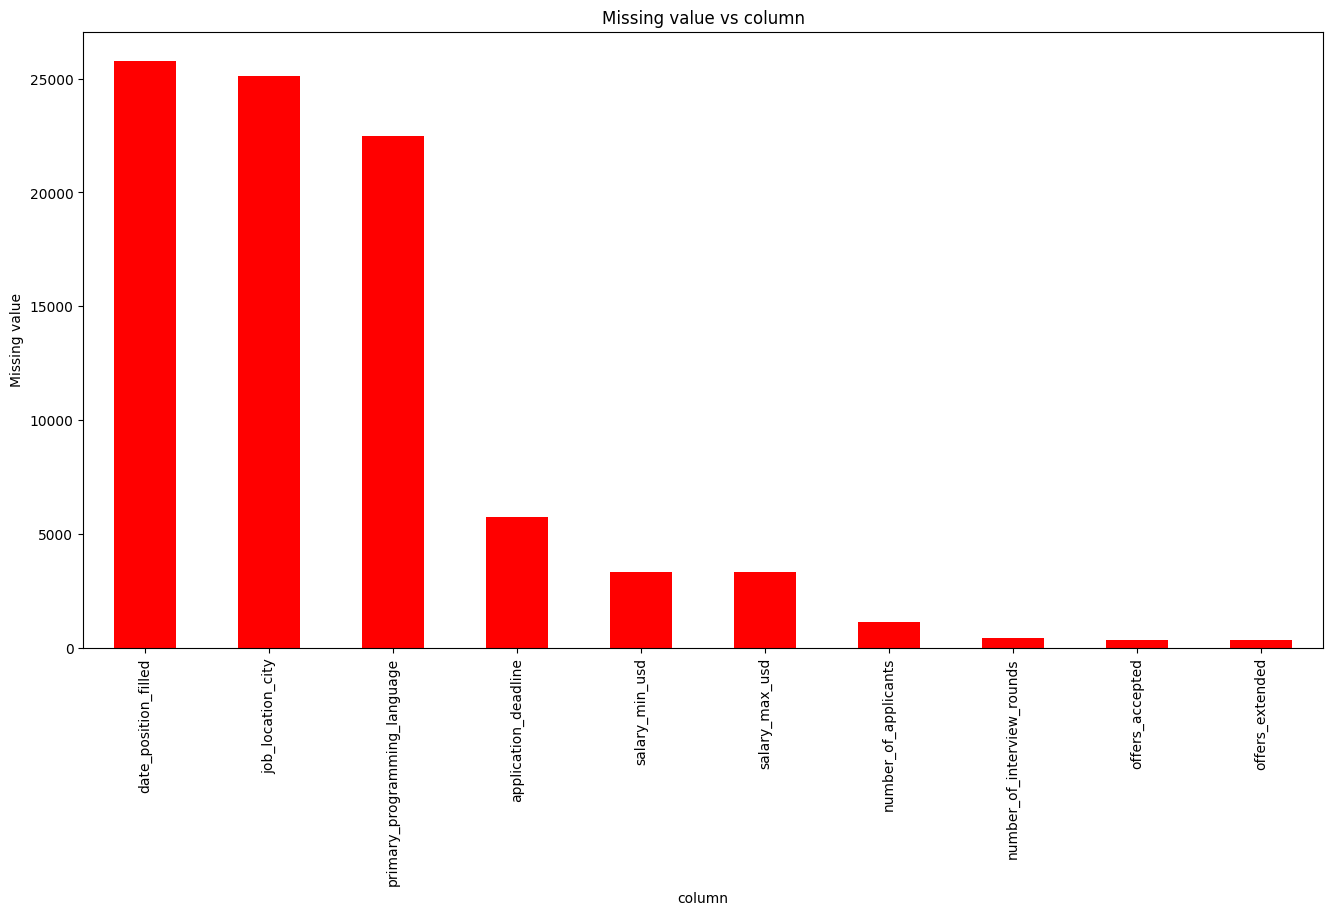

In [ ]:
# Graph
a.sort_values(ascending=False).plot(kind='bar',color='red',figsize=(16,8))
plt.title('Missing value vs column')
plt.xlabel('column')
plt.ylabel('Missing value')


In [ ]:
df.isnull().sum().sum()

np.int64(87962)

In [ ]:
# Duplicate Analysis
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
114995,False
114996,False
114997,False
114998,False


In [ ]:
df.duplicated().sum()

np.int64(1193)

In [ ]:
df[df.duplicated()]

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
1584,JOB002656,DriftGame Co,MNC,EdTech,156326,USA,Data Scientist,Senior,6,8,...,2024-02-19 00:00:00,2024-02-07,Filled,99.0,5.0,1.0,1.0,153600.0,188500.0,False
2216,JOB000563,NexusCompute,FAANG-tier,Crypto/Web3,142214,Brazil,DevOps Engineer,Senior,4,10,...,2019-08-31 00:00:00,2019-09-22,Filled,90.0,4.0,1.0,1.0,185600.0,247000.0,1
2969,JOB073226,BeaconPixel,MNC,Cloud/Infra,74335,Germany,Backend Engineer,Mid,1,4,...,2022-09-14 00:00:00,NaN,Cancelled,244.0,2.0,0.0,0.0,139200.0,168900.0,No
3897,JOB022039,BeaconStack Co,MNC,AI/ML,277054,USA,Infrastructure Engineer,Entry,0,2,...,2026-01-24 00:00:00,2026-03-21,Filled,123.0,3.0,1.0,1.0,99300.0,119700.0,N
4327,JOB006733,SummitShield Co,Mid-size,E-commerce,5508,UK,Platform Engineer,Senior,5,11,...,2021-03-26 00:00:00,2021-05-07,Filled,54.0,4.0,1.0,1.0,92900.0,120300.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114639,JOB110813,BeaconStack Co,MNC,AI/ML,245179,USA,Mobile Engineer (Android),Entry,0,2,...,2019-05-09 00:00:00,NaN,Cancelled,249.0,3.0,0.0,0.0,NaN,NaN,False
114824,JOB100893,AnchorBuzz Labs,MNC,HealthTech,157695,USA,QA Engineer,Intern,0,1,...,2023-04-30 00:00:00,2023-05-11,Filled,322.0,3.0,1.0,1.0,27700.0,36300.0,False
114866,JOB110283,CobaltWealth,MNC,HealthTech,136976,Germany,Embedded Systems Engineer,Senior,5,8,...,NaN,2021-05-15,Filled,77.0,5.0,1.0,1.0,-1,-1,False
114871,JOB035395,AetherAI Co,MNC,AI/ML,208677,UK,Infrastructure Engineer,Lead,7,15,...,2020-08-06 00:00:00,2020-09-11,Filled,30.0,6.0,1.0,1.0,296800.0,363500.0,No


In [ ]:
# Numerical columns
num_col=df.select_dtypes(include=np.number).columns
num_col

Index(['company_size_employees', 'years_experience_min',
       'years_experience_max', 'number_of_applicants',
       'number_of_interview_rounds', 'offers_extended', 'offers_accepted'],
      dtype='object')

In [ ]:
df[num_col].describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,115000.000000,115000.000000,115000.000000,113890.000000,114564.000000,114670.000000,114670.000000
mean,105386.103122,3.004452,6.665443,181.659215,3.307653,1.349786,1.196634
std,102117.290040,3.093383,5.073654,436.344753,1.418283,1.457267,1.122837
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6038.750000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88364.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169840.250000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [ ]:
# Categorical consistency
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(col)
    print("Unique:", df[col].nunique())
    print(df[col].value_counts().head(15))

job_id
Unique: 113000
job_id
JOB001361    3
JOB051125    3
JOB055551    3
JOB004262    3
JOB007136    3
JOB054307    3
JOB080699    3
JOB088269    3
JOB086783    2
JOB011000    2
JOB036102    2
JOB086716    2
JOB016573    2
JOB080687    2
JOB089465    2
Name: count, dtype: int64
company_name
Unique: 898
company_name
NexusShield                 3265
MeridianToken               3201
RidgeFreight Labs           3106
SpireCloud                  3030
AetherAI Co                 2746
EchoFreight Systems         2666
BeaconStack Co              2536
AnchorBuzz Labs             2522
DriftGame Co                2438
MeridianShield Labs         2401
OrbitNeural Technologies    2273
NovaFleet                   2229
FusionTrade                 2223
NexusCompute                2220
AstraSuite                  2092
Name: count, dtype: int64
company_type
Unique: 5
company_type
MNC           56053
Mid-size      20305
Unicorn       16078
FAANG-tier    15963
Startup        6601
Name: count, dtype: int64

In [ ]:
# logical and referencial checks
# Experience
df[df['years_experience_max'] < df['years_experience_min']]

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
131,JOB031986,DriftSkill Inc,MNC,E-commerce,126266,Canada,Mobile Engineer (Android),Entry,4,1,...,2024-12-17 00:00:00,NaN,Cancelled,186.0,2.0,1.0,1.0,58600.0,66200.0,No
133,JOB089059,CatalystHub Co,Unicorn,AI/ML,3541,Ireland,Backend Engineer,Mid,7,2,...,2024-09-06 00:00:00,2024-08-16,Filled,123.0,3.0,1.0,1.0,137000.0,156600.0,N
679,JOB101867,NimbusGame Technologies,Mid-size,EdTech,4008,Germany,Site Reliability Engineer,Senior,8,4,...,2022-03-28 00:00:00,2022-03-24,Filled,28.0,5.0,1.0,1.0,149600.0,187300.0,No
1943,JOB011486,FusionTrade,MNC,Fintech,165215,UAE,Mobile Engineer (Android),Mid,7,2,...,2026-02-12 00:00:00,2026-03-12,Filled,91.0,2.0,1.0,1.0,Not Disclosed,Not Disclosed,False
2301,JOB101144,FusionTrade,MNC,Fintech,159001,UAE,Full Stack Engineer,Mid,6,2,...,2024-05-21 00:00:00,2024-05-26,Filled,247.0,4.0,4.0,3.0,98600.0,123100.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113800,JOB018427,VertexBlock Inc,MNC,Gaming,108196,India,Embedded Systems Engineer,Senior,10,6,...,2024-07-07 00:00:00,2024-08-23,Filled,79.0,5.0,1.0,1.0,182400.0,203900.0,False
114117,JOB069657,TideSentinel Technologies,Unicorn,HealthTech,13181,UK,Analytics Engineer,Senior,8,6,...,2025-03-26 00:00:00,2025-04-17,Filled,54.0,5.0,1.0,1.0,219000.0,285100.0,N
114292,JOB023878,AetherAI Co,MNC,AI/ML,243023,UK,Embedded Systems Engineer,Entry,4,0,...,2025-04-19 00:00:00,NaN,Withdrawn,93.0,2.0,0.0,0.0,96600.0,128300.0,Yes
114629,JOB085791,MeridianToken,MNC,EdTech,358354,USA,QA Engineer,Entry,3,0,...,2020-04-07 00:00:00,2020-05-28,Filled,234.0,1.0,1.0,1.0,76700.0,102600.0,False


In [ ]:
# salary
df[df['salary_max_usd'] < df['salary_min_usd']]

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,...,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
7,JOB057551,EchoCortex Co,MNC,Cybersecurity,128882,USA,Embedded Systems Engineer,Entry,0,4,...,2024-05-25 00:00:00,2024-05-29,Filled,258.0,3.0,1.0,1.0,131100.0,103900.0,N
14,JOB015507,QuantumBuzz Technologies,MNC,SaaS,116690,UK,Backend Engineer,Mid,1,6,...,2019-01-22 00:00:00,2019-04-23,Filled,126.0,3.0,1.0,1.0,82600.0,106100.0,0
18,JOB014227,LumenArcade Technologies,MNC,Logistics,123108,France,Platform Engineer,Senior,5,9,...,2023-05-23 00:00:00,2023-06-24,Filled,44.0,4.0,1.0,1.0,96900.0,117400.0,0
48,JOB101281,SolaceShop Labs,Mid-size,EdTech,4417,India,Data Analyst,Senior,6,8,...,2025-02-25 00:00:00,2025-02-10,Filled,67.0,3.0,1.0,1.0,93400.0,125000.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114978,JOB059417,DriftSkill Inc,MNC,E-commerce,118246,Canada,Platform Engineer,Mid,3,6,...,2026-06-16 00:00:00,NaN,Cancelled,52.0,4.0,1.0,1.0,96400.0,128900.0,0
114982,JOB006051,LumenArcade Technologies,MNC,Logistics,139163,France,Product Manager,Mid,2,5,...,NaN,2025-12-12,Filled,60.0,4.0,1.0,1.0,97100.0,118200.0,0
114984,JOB112680,RuneCompute,Mid-size,AI/ML,4200,Netherlands,Mobile Engineer (Android),Mid,1,7,...,2026-02-16 00:00:00,2026-02-26,Filled,186.0,3.0,1.0,1.0,84500.0,111500.0,No
114988,JOB046390,DriftGame,Unicorn,HealthTech,13786,India,Product Designer,Entry,1,3,...,2022-04-02 00:00:00,2022-03-04,Filled,101.0,2.0,4.0,3.0,96300.0,120600.0,True


In [ ]:
# offers
df[df['offers_accepted'] > df['offers_extended']]

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,...,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
6,JOB080320,SpireCloud,MNC,Fintech,369939,USA,UI Designer,Entry,0,1,...,2022-06-16 00:00:00,2022-06-09,Filled,281.0,1.0,1.0,3.0,87400.0,98100.0,False
122,JOB015271,PinnacleLedger Labs,FAANG-tier,Social/AdTech,91663,USA,Embedded Systems Engineer,Mid,2,5,...,2021-03-02 00:00:00,2021-03-29,Filled,160.0,3.0,7.0,9.0,178100.0,223900.0,0
268,JOB080660,NimbusFlow,FAANG-tier,Crypto/Web3,85062,UK,Mobile Engineer (Android),Senior,5,11,...,2025-03-23 00:00:00,2025-04-10,Filled,122.0,6.0,7.0,9.0,178500.0,197900.0,No
849,JOB084218,DriftNeural Systems,Mid-size,E-commerce,4709,Singapore,Application Security Engineer,Intern,0,2,...,2025-04-19 00:00:00,NaN,Cancelled,174.0,1.0,1.0,3.0,20100.0,27100.0,N
976,JOB048731,VertexBlock Inc,MNC,Gaming,90434,India,Penetration Tester,Mid,3,4,...,2026-03-15 00:00:00,2026-04-24,Filled,128.0,3.0,1.0,3.0,100700.0,115400.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114530,JOB066528,BeaconPixel,MNC,Cloud/Infra,66559,Germany,Associate Product Manager,Mid,2,6,...,2024-06-16 00:00:00,2024-06-13,Filled,84.0,4.0,1.0,3.0,103400.0,119700.0,No
114618,JOB063410,MarrowChain Systems,Unicorn,E-commerce,9008,Brazil,Product Manager,Lead,8,16,...,2026-03-06 00:00:00,2026-03-19,Filled,31.0,6.0,1.0,3.0,201500.0,253800.0,False
114720,JOB095411,AetherAI Co,MNC,AI/ML,236524,UK,Mobile Engineer (Android),Principal,12,22,...,2026-03-31 00:00:00,NaN,Open,16.0,5.0,6.0,7.0,211500.0,269400.0,0
114880,JOB033223,OnyxBuzz Inc,Unicorn,Social/AdTech,12011,USA,Embedded Systems Engineer,Mid,3,4,...,2026-06-11 00:00:00,2026-05-26,Filled,130.0,2.0,1.0,3.0,140100.0,161500.0,N


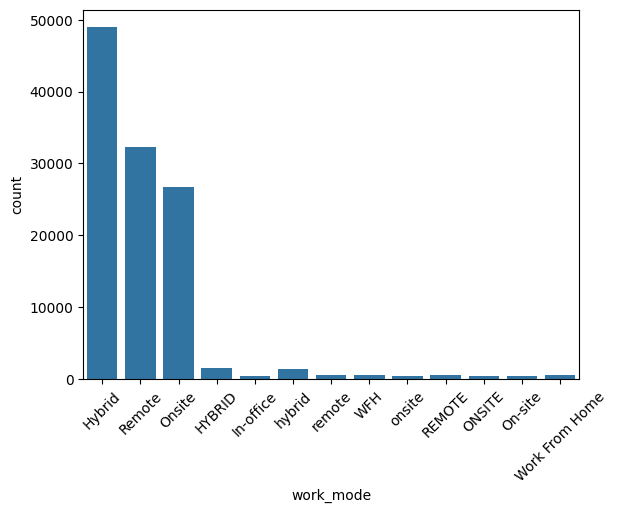

In [ ]:

#Univariate
sns.countplot(data=df, x='work_mode')
plt.xticks(rotation=45)
plt.show()

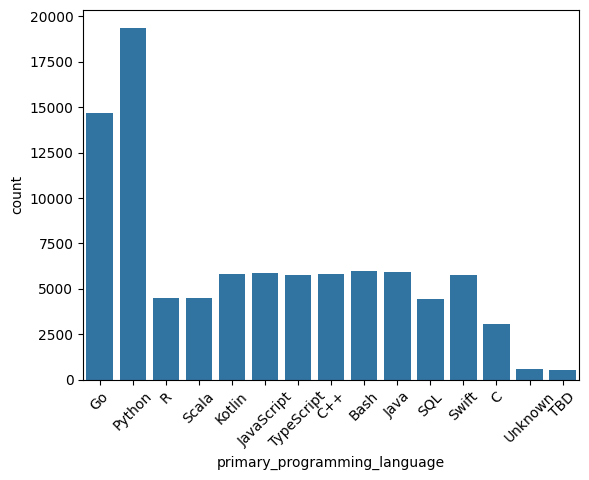

In [ ]:
sns.countplot(data=df, x='primary_programming_language')
plt.xticks(rotation=45)
plt.show()

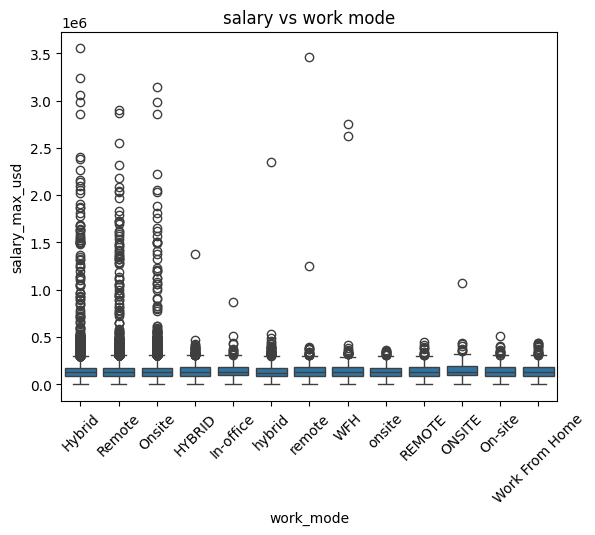

In [ ]:
# Bivariate analysis
df['salary_max_usd']=pd.to_numeric(df['salary_max_usd'],errors='coerce')
sns.boxplot(data=df,x='work_mode',y='salary_max_usd')
plt.xticks(rotation=45)
plt.title('salary vs work mode')
plt.show()



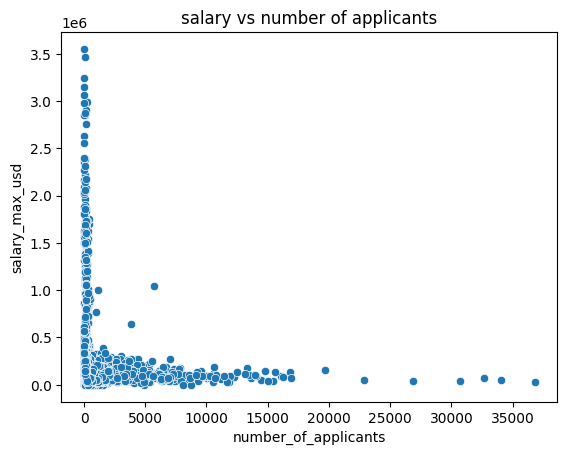

In [ ]:

sns.scatterplot(data=df,x='number_of_applicants',y='salary_max_usd')
plt.title('salary vs number of applicants')
plt.show()

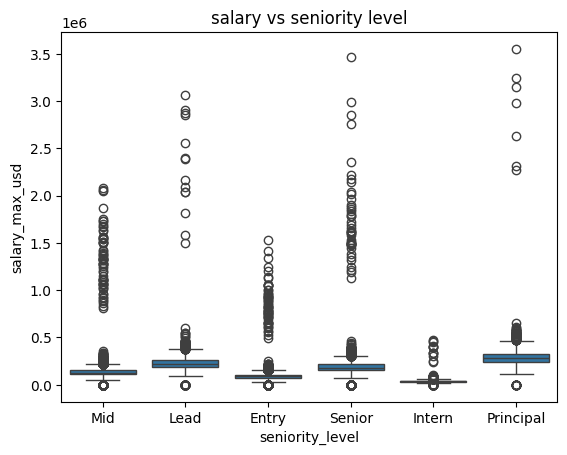

In [ ]:
sns.boxplot(data=df,x='seniority_level',y='salary_max_usd')
plt.title('salary vs seniority level')
plt.show()

In [ ]:
# Time based analysis
df['posting_date']=pd.to_datetime(df['posting_date'])

In [ ]:
df['year']=df['posting_date'].dt.year

In [ ]:
yearly_jobs=df['year'].value_counts().sort_index()
yearly_jobs

,count
year,
2019,11592
2020,9788
2021,13799
2022,13621
2023,10497
2024,19471
2025,20677
2026,15555


Text(0.5, 1.0, 'number of jobs vs year')

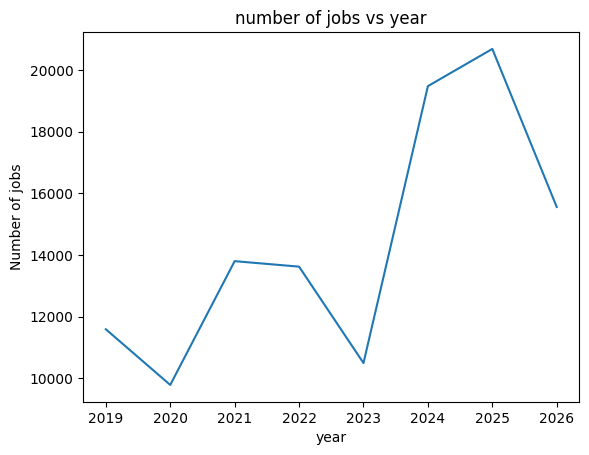

In [ ]:
plt.plot(yearly_jobs.index,yearly_jobs.values)
plt.xlabel('year')
plt.ylabel('Number of jobs')
plt.title('number of jobs vs year')

In [ ]:
# Future Engineering
df['salary_min_usd']=pd.to_numeric(df['salary_min_usd'],errors='coerce')
df['salary_max_usd']=pd.to_numeric(df['salary_max_usd'],errors='coerce')

In [ ]:
b=df['average_salary']=(df['salary_min_usd']+df['salary_max_usd'])/2
b

,0
0,-1.0
1,NaN
2,256750.0
3,100150.0
4,NaN
...,...
114995,234800.0
114996,100500.0
114997,141200.0
114998,165050.0


In [ ]:
df['date_position_filled']=pd.to_datetime(df['date_position_filled'],errors='coerce')
df['posting_date']=pd.to_datetime(df['posting_date'],errors='coerce')

In [ ]:
days=df['time_to_fill_days']=(df['date_position_filled']-df['posting_date']).dt.days
days

,0
0,60.0
1,NaN
2,69.0
3,30.0
4,74.0
...,...
114995,57.0
114996,NaN
114997,NaN
114998,NaN


In [ ]:
Ratio=df['offer_accept_ratio'] = (df['offers_accepted'] / df['offers_extended'])
Ratio

,0
0,1.000000
1,0.000000
2,1.000000
3,0.833333
4,1.000000
...,...
114995,1.000000
114996,0.000000
114997,1.000000
114998,1.000000


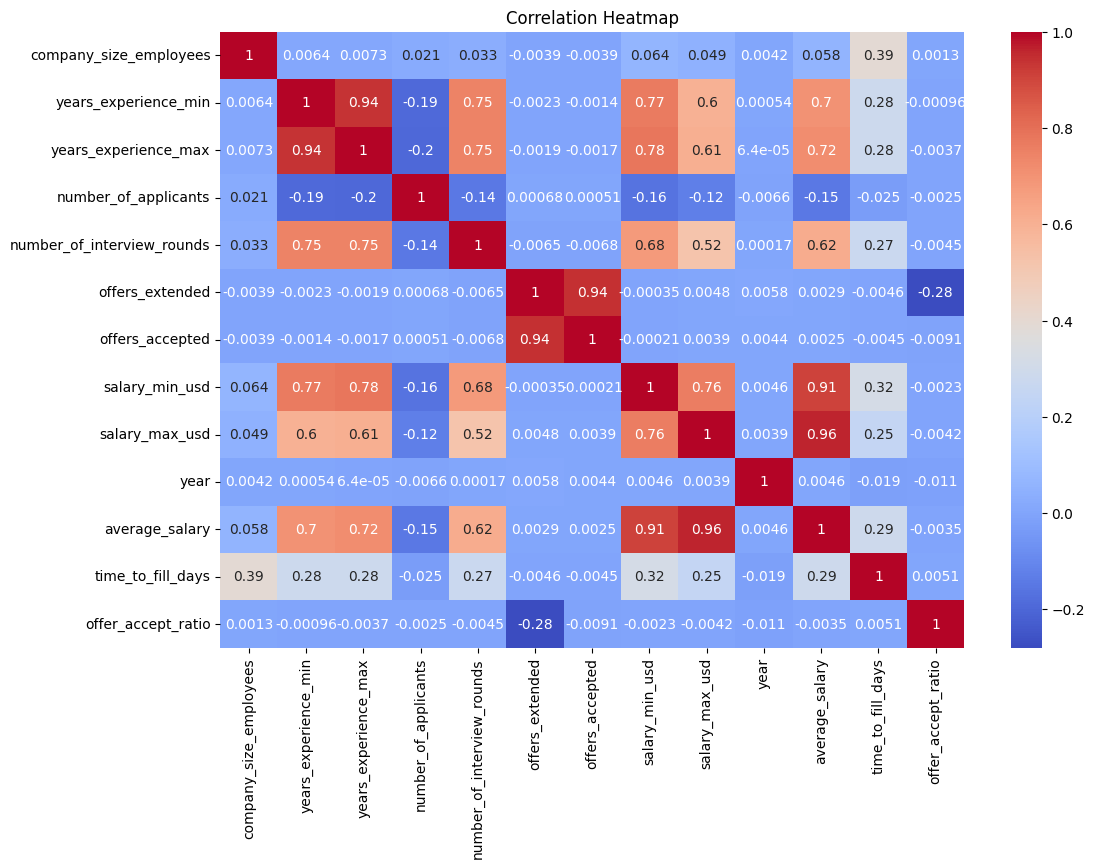

In [ ]:
# Correlation Analysis
numeric_cols = df.select_dtypes(include='number')
correlation = numeric_cols.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

 Task 2: supervised Learning Algorithms

In [ ]:
df.shape

(115000, 32)

### Salary Data Cleaning

The salary columns contain missing and placeholder values. Placeholder values such as -1 are treated as missing values before calculating the target salary.

In [ ]:
df['salary_min_usd'] = pd.to_numeric(
    df['salary_min_usd'], errors='coerce'
)

df['salary_max_usd'] = pd.to_numeric(
    df['salary_max_usd'], errors='coerce'
)

df['salary_min_usd'] = df['salary_min_usd'].replace(-1, np.nan)
df['salary_max_usd'] = df['salary_max_usd'].replace(-1, np.nan)

### Target Selection

The dataset does not provide a direct target column for expected salary. Therefore, average_salary is derived from salary_min_usd and salary_max_usd. It represents the midpoint of the reported salary range.

In [ ]:
df['average_salary'] = (
    df['salary_min_usd'] + df['salary_max_usd']
) / 2

In [ ]:
df_model = df.dropna(subset=['average_salary']).copy()

In [ ]:
df_model.shape

(108875, 32)

### Feature Selection

Salary_min_usd and salary_max_usd are not used as input features because average_salary is calculated directly from these two columns. Using them would give the model direct information about the target.

In [ ]:
feature_cols = [
    'company_type',
    'sector',
    'hq_country',
    'job_role',
    'seniority_level',
    'required_tech_stack',
    'primary_programming_language',
    'work_mode',
    'visa_sponsorship_offered',
    'job_location_country',
    'job_location_city',
    'position_status',
    'years_experience_min',
    'years_experience_max',
]

x = df_model[feature_cols]
y = df_model['average_salary']

In [ ]:
x.shape

(108875, 14)

In [ ]:
y.shape

(108875,)